<font size="5">**Dataframe e Serie di *pandas***</font><br>

> (c) 2026 Antonio Michele Piemontese

Il package *pandas* di Python serve a gestire i **dataframe** e le **serie**.

# Rilevamento ambiente di sviluppo

In [1]:
# impostazione del TOGGLE BINARIO:
try:
    import google.colab                      # package disponibile SOLO in Google Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running on Colab:", IN_COLAB)


# IMPORT dei package necessari (necessari sia in JN che in Colab):
from IPython.display import Image, display   # import dei package di incorporamento e visualizzazione immagine (una tantum)
                                             # Image e display sono entrambi necessari a Jupyter Notebook
                                             # Google Colab utilizza solo Image
import os                                    # necessario a Google Colab per vedere da una cella codice
                                             # i contenuti del 'content'

Running on Colab: False


# Legenda delle icone (standard)
Legenda delle icone (standard) usate nel notebook (per garantire consistenza semantica):

👉 punto di attenzione, il "succo"<br>
📌 nota / inizio di una nota<br>
📦 punto elenco importante<br>
📊 dati/numeri<br>
🔹 punto elenco normale<br>
⭐ punto elenco importante<br>
✅ punto risolto, positivo<br>
❌ punto negativo, da evitare<br>
⚠️ attenzione, warning, allarme<br>
💡 idea chiave<br>
🧠 idea intuitiva<br>
📝 sintesi / bottom-line<br>
⟶ conseguenza, effetto, passo successivo

# Importazione package

In Google Colab i principali package python sono già installati. Occorre comunque farne l'importazione notebook.
Secondo le linee guida di scrittura del codice Python ([PEP8](https://peps.python.org/pep-0008/)) **le import vanno fatte tutte ad inizio script/notebook**.

In [2]:
import pandas as pd     # importazione in memoria del package pandas (già installato di default in Google Colab);
                        # non confondere la installazione di un package con la import: la prima installa SU DISCO e si fa una volta sola (alcuni package
                        # sono già pre-installati); la seconda carica il package IN MEMORIA e dunque va fatta ad ogni nuova esecuzione del notebook

# Lettura del dataset

La  funzione `read_csv` è fornita da pandas, vedi [qui](https://pandas.pydata.org/) per la sua documentazione.

In [3]:
df = pd.read_csv(filepath_or_buffer='Credit_ISLR.csv', sep=",",header=0)   # questa riga dà errore --> occorre fare l'upload del file csv nella session storage

**Note sul precedente comando**:
* attenzione al  parametro `sep`: è la virgola o il punto e virgola (nel nostro file csv)
* attenzione al parametro 'header':
  - `header=0` considera la prima riga come nomi colonna
  - `header=1` considera le prime 2 righe come interazioni
  - `header=None` considera la prima riga come dati
* specificare sempre il formato del file (.csv)
* se il path contiene solo il nome del  file, Colab/VSC lo cerca nella cartella corrente

Qual è  la cartella corrente? in VS Code è la cartella del PC dal quale abbiamo attivato il notebook.In Colab è ***content***.

Si verifica con il comando magic: **%pwd**:





In [4]:
%pwd     # è un comando magico di Jupyter Notebook che mostra la directory di lavoro corrente (current working directory) in cui si trova il notebook; 
         # è utile per capire dove siamo e dove dobbiamo mettere i file da caricare

'c:\\Users\\Utente\\Desktop\\salvataggi\\SALVATAGGIO DATI\\Documents\\Seminari\\Data Science (corsi)\\Repository GitHub corsi\\Corso Python Unicredit (giugno 2026)\\Corso Python per Unicredit - ediz. 1 (giugno 2026)'

In [5]:
# la documentazione della funzione 'read_csv' di pandas è disponibile a questo link: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html
?pd.read_csv

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[HashableT, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: 

---
pandas fornisce un insieme di funzioni chiamate **read_XXXX** per leggere file di molti formati. Vedi in proposito [questa chat](https://chatgpt.com/share/68e6379c-a2f4-8012-b0cd-615ff6a2ac74).

---

Il file ***Credit*** è un famoso file bancario che contiene 400 clienti di carte di credito descritti lungo una decina di attributi. E' un file simulato negli anni '90 ed è molto usato per imparare python e pandas.

# Esame del dataset

In [6]:
df.head()               # le prime 5 righe

,Unnamed: 0,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [7]:
df.tail()               # le ultime 5 righe

,Unnamed: 0,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
395,396,396,12.096,4100,307,3,32,13,Male,No,Yes,Caucasian,560
396,397,397,13.364,3838,296,5,65,17,Male,No,No,African American,480
397,398,398,57.872,4171,321,5,67,12,Female,No,Yes,Caucasian,138
398,399,399,37.728,2525,192,1,44,13,Male,No,Yes,Caucasian,0
399,400,400,18.701,5524,415,5,64,7,Female,No,No,Asian,966


**Rimuoviamo** dal dataframe 'df' le colonne inutili:
- *Unnamed: 0*: inserita dalla funzione 'pd.read_csv'
- *ID*: un identificativo numerico del cliente presente nel file CSV. Numera da 1 anzichè da 0, come deve essere in Python; inoltre è ridondante rispetto all'indice che pandas crea in automatico (la prima colonna a sx in grassetto).

In [9]:
df.drop(columns=['Unnamed: 0','ID'])  # la drop, con questa sintassi, elimina le due colonne temporaneamente (cioè solo nel display dell'output della funzione)
                                    

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331
...,...,...,...,...,...,...,...,...,...,...,...
395,12.096,4100,307,3,32,13,Male,No,Yes,Caucasian,560
396,13.364,3838,296,5,65,17,Male,No,No,African American,480
397,57.872,4171,321,5,67,12,Female,No,Yes,Caucasian,138
398,37.728,2525,192,1,44,13,Male,No,Yes,Caucasian,0


In [10]:
df.head()   # le due colonne ci sono ancora!!

,Unnamed: 0,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [11]:
df.drop(columns=['Unnamed: 0','ID'],inplace=True)  # in-place = True rende l'operazione di drop PERSISTENTE (in memoria).
                                                   # ⚠️ questo comando può essere eseguito solo una volta, perché le colonne vengono eliminate dal dataframe 
                                                   # e non sono più disponibili per successive esecuzioni della cella codice

In [12]:
display(df)       # display è una FUNZIONE, non un metodo

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331
...,...,...,...,...,...,...,...,...,...,...,...
395,12.096,4100,307,3,32,13,Male,No,Yes,Caucasian,560
396,13.364,3838,296,5,65,17,Male,No,No,African American,480
397,57.872,4171,321,5,67,12,Female,No,Yes,Caucasian,138
398,37.728,2525,192,1,44,13,Male,No,Yes,Caucasian,0


---
> La funzione `display` visualizza le righe e colonne di un dataframe in formato **HTML / CSS** (a differenza della funzione `print`).
>
> Come si vede, le due colonne "droppate" non sono più presenti nel dataframe.

---

In [13]:
print(df)  # al contrario la funzione 'print' visualizza il dataframe in un  formato più sdemplice (senza CSS)

      Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0     14.891   3606     283      2   34         11    Male      No     Yes   
1    106.025   6645     483      3   82         15  Female     Yes     Yes   
2    104.593   7075     514      4   71         11    Male      No      No   
3    148.924   9504     681      3   36         11  Female      No      No   
4     55.882   4897     357      2   68         16    Male      No     Yes   
..       ...    ...     ...    ...  ...        ...     ...     ...     ...   
395   12.096   4100     307      3   32         13    Male      No     Yes   
396   13.364   3838     296      5   65         17    Male      No      No   
397   57.872   4171     321      5   67         12  Female      No     Yes   
398   37.728   2525     192      1   44         13    Male      No     Yes   
399   18.701   5524     415      5   64          7  Female      No      No   

            Ethnicity  Balance  
0           Caucasian      333

Cosa ne è stato delle righe del dataframe `df` di mezzo, non visualizzate prima. Per vedere **tutte** le righe di un dataframe dobbiamo **settare alcune impostazioni** di pandas (**solo per questo output**):

In [14]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(df)

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331
5,80.180,8047,569,4,77,10,Male,No,No,Caucasian,1151
6,20.996,3388,259,2,37,12,Female,No,No,African American,203
7,71.408,7114,512,2,87,9,Male,No,No,Asian,872
8,15.125,3300,266,5,66,13,Female,No,No,Caucasian,279
9,71.061,6819,491,3,41,19,Female,Yes,Yes,African American,1350


In [ ]:
display(df)   # i valori dei due parametri "display.max_rows" e "display.max_columns" sono tornati ai valori di default (5+5)

# Funzione vs metodo

Sia le funzioni che i metodi sono **blocchi di codice** <u>richiamabili</u> che accettano una lista di **parametri di input opzionali**, indicati tra <u>parentesi tonde ()</u>.

La differenza sta in come si richiamano.

Una funzione si richiama partendo **dal suo nome**:

In [15]:
lista = [1,2,3,4,5]        # una lista è una collezione di valori (anche di tipo diverso) racchiusi tra parentesi quadre e separati da virgole
print(len(lista))          # la funzione 'len' restituisce il numero di elementi di una lista (o di un'altra collezione)
print("ciao")              # la funzione 'print' visualizza una stringa (o un numero o un'altra cosa) in un formato semplice, senza CSS

5
ciao


Un metodo **si applica a un oggetto di una classe**, tramite la [*dot notation*](https://realpython.com/ref/glossary/dot-notation/#:~:text=It%20provides%20a%20way%20to,Python%20code%20intuitive%20and%20readable.):

In [16]:
lista.append(6)
print(lista)
testo = "ciao"
testo.upper()          # restituisce la stringa in maiuscolo

[1, 2, 3, 4, 5, 6]


'CIAO'

Un metodo appartiene a **una classe** (verificabile con la funzione Python nativa `type()`): se un oggetto appartiene a una certa classe, **eredita automaticamente tutti i metodi di quella classe**. Per esempio, ogni oggetto di tipo python `str` può usare i metodi `.upper()`, `.split()`, `.replace()`, perché sono <u>metodi della classe `str`</u>.

Infine, sia le funzioni che i metodi possono essere:
* **nativi** di Python: es. la funzione `len()`, il metodo `.append()`,
* forniti da un **package**: es. `np.array()`, oppure `df.head()`,
* definiti dall'utente (le funzioni con `def`, o i metodi nelle classi che scriviamo noi).

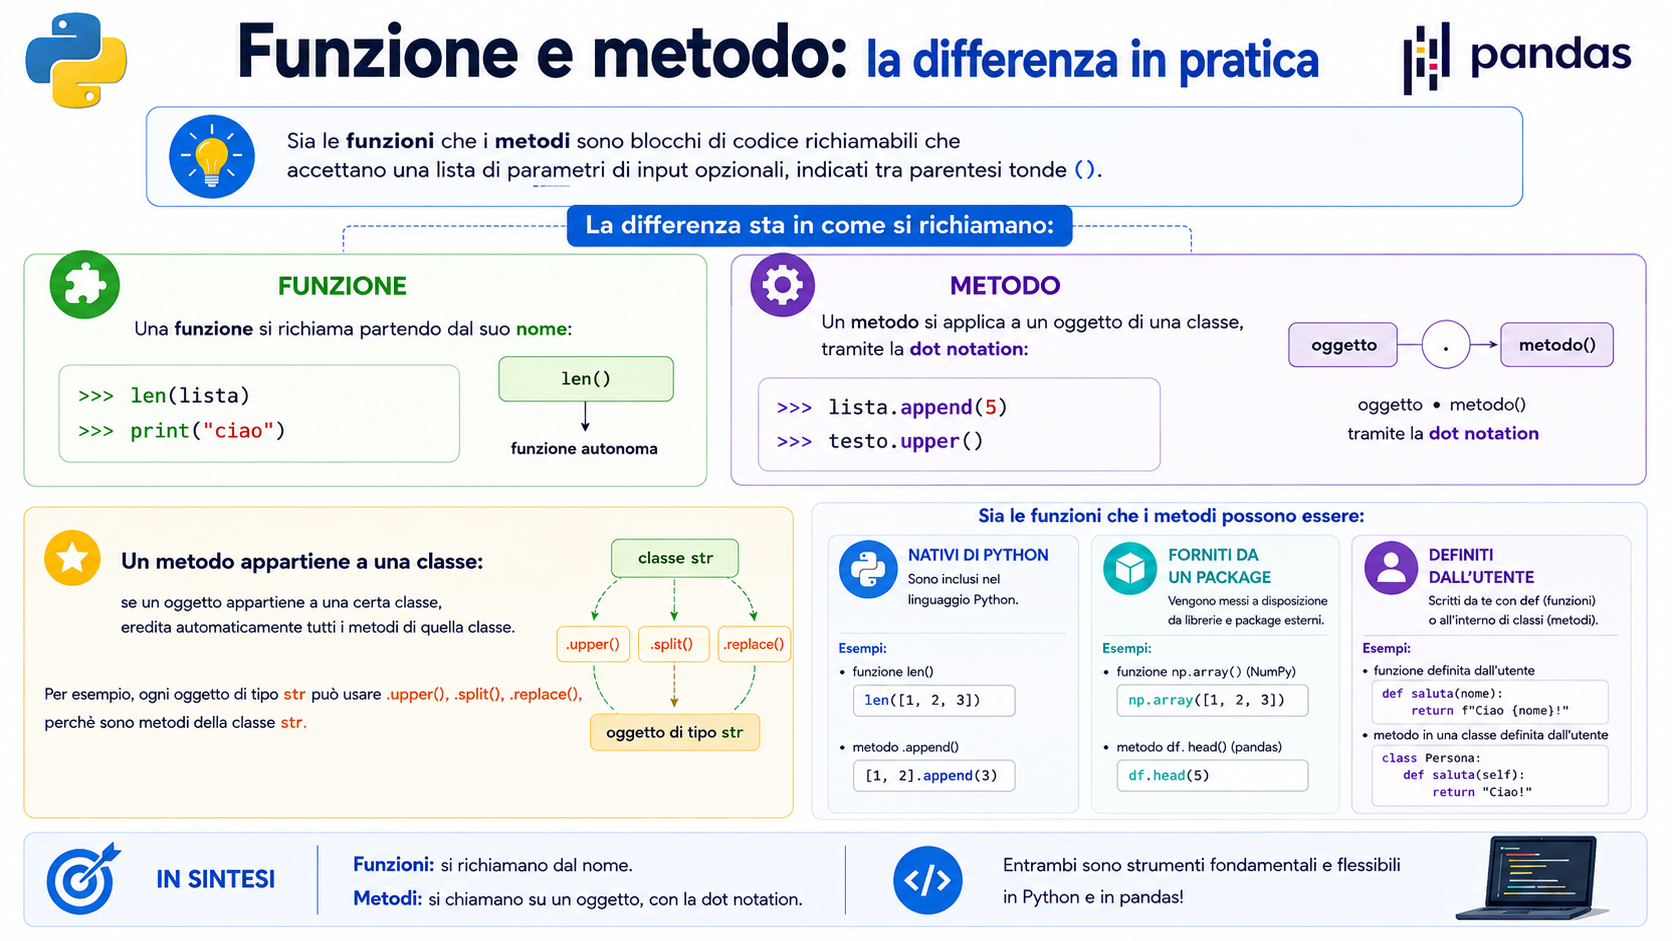

In [17]:
Image('funzione_vs_metodo.png') if IN_COLAB else display(Image(filename='funzione_vs_metodo.png'))

Verifica della **classe** dell'oggetto `df`:


In [18]:
type(df)              # la classe dell'oggetto --> è un dataframe perchè è stato creato con la funzione 'pd.read_csv' di pandas

pandas.DataFrame

# I data type elementari di pandas

Abbiamo detto prima che pandas ha due tipi di data type **aggregati**: il dataframe (bi-dimensionale) e la serie (mono-dimensionale).<br>
👉 Ma pandas ha anche diversi **datatype elementari** (applicabili cioè alle singole colonne):

In [19]:
df.dtypes    # il metodo 'dtypes' restituisce il tipo di dato di ogni colonna del dataframe; 
             # è un metodo che funziona solo per i dataframe, non per le serie di pandas (anche se la serie contiene una sola colonna)

Income       float64
Limit          int64
Rating         int64
Cards          int64
Age            int64
Education      int64
Gender           str
Student          str
Married          str
Ethnicity        str
Balance        int64
dtype: object

Purtroppo, le colonne di un dataframe pandas di tipo "stringa alfanumerica" sono chiamate **object** (un termine non felice).

📌 **Come evitare il datatype 'object'**<br>
Al momento del caricamento del file *csv*, pandas (la funzione `read_csv`) **inferisce** i datatype dai valori delle colonne del file CSV, ed a volte commette degli errori. Dobbiamo usare il parametro `dtype`.

In [20]:
df = pd.read_csv(filepath_or_buffer='Credit_ISLR.csv', sep=",",header=0, dtype={"Gender": "category","Student": "category","Married": "category"})
df.drop(columns=['Unnamed: 0','ID'],inplace=True)  # la drop, con questa sintassi, elimina le due colonne temporaneamente (cioè solo nel display dell'output della funzione)

In [21]:
df.dtypes

Income        float64
Limit           int64
Rating          int64
Cards           int64
Age             int64
Education       int64
Gender       category
Student      category
Married      category
Ethnicity         str
Balance         int64
dtype: object

# I dataframe di pandas

**Cosa è un dataframe in pandas?**<br>
E' una TABELLA di righe e colonne **in memoria**. Non è la classica tabella SQL (su **disco**).

Vediamonne le **dimensioni** (con la relativa **cardinalità**):

In [22]:
df.shape

(400, 11)

Il dataframe `df` ha 2 dimensioni di cardinalità 400 e 11.

L'elenco dei data-type pandas **elementari** del `df` (cioè delle singole colonne) è fornito dal metodo `dtypes`.

In [23]:
df.dtypes

Income        float64
Limit           int64
Rating          int64
Cards           int64
Age             int64
Education       int64
Gender       category
Student      category
Married      category
Ethnicity         str
Balance         int64
dtype: object

Quante celle contiene il dataframe?

In [24]:
df.size

4400

# Valori mancanti

Questo dataset NON ha valori mancanti. Ma, in generale, una domanda preliminare molto importante, è appunto se il dataframe contiene valori mancanti (detti **missing values** oppure **not available**). Si fa con il metodo 'isna' che funziona in questo modo:
- lavora in modo parrallelo su righe e colonne (vettorizzazione)
- esegue il test sulla **singola cella**
- e quindi restituisce una matrice di booleani (True oppure False) con l'esito del test per ogni cella.

In [25]:
df.isna()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
395,False,False,False,False,False,False,False,False,False,False,False
396,False,False,False,False,False,False,False,False,False,False,False
397,False,False,False,False,False,False,False,False,False,False,False
398,False,False,False,False,False,False,False,False,False,False,False


Occorre individuare le celle con **True** (i MV). Per dataset medio-grandiun controllo visivo è di fatto impossibile.

Per fortuna, il valore booleano True è memorizzato nei PC come 1, ed il valore False come 0.

In [ ]:
df.isna().sum()   # chaining di metodi (in cascata)

Income       0
Limit        0
Rating       0
Cards        0
Age          0
Education    0
Gender       0
Student      0
Married      0
Ethnicity    0
Balance      0
dtype: int64

# Analisi del dataframe

Ora un pò di **analisi** di questo dataframe:

In [27]:
df.info()          # fornisce una SINTESI di informazioni sul dataframe
                   # - la classe alla quale l'oggetto appartiene
                   # - il range dei valori dell'indice (la prima colonna in grassetto inserita automaticamente da pandas)
                   # - i data type delle varie colonne, con l'indicazione se contengono valori mancanti (e quanti)
                   # - un riassunto finale dei datatype utilizzati (e quanti)
                   # - l'occupazione di memoria del dataframe

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Income     400 non-null    float64 
 1   Limit      400 non-null    int64   
 2   Rating     400 non-null    int64   
 3   Cards      400 non-null    int64   
 4   Age        400 non-null    int64   
 5   Education  400 non-null    int64   
 6   Gender     400 non-null    category
 7   Student    400 non-null    category
 8   Married    400 non-null    category
 9   Ethnicity  400 non-null    str     
 10  Balance    400 non-null    int64   
dtypes: category(3), float64(1), int64(6), str(1)
memory usage: 30.4 KB


`float64` è un numero a virgola  mobile in doppia precisione (cioè con i decimali e allocato su 64 bit).<br>
`int64` è un numero intero allocato su 64 bit<br>
`object` è una stringa alfanumerica


⚠️ Il comando `df.info`, senza le due parentesi tonde, non dà errore, ma fornisce un altro risultato, completamente differente e fuori contesto.

Quasi sempre i metodi devono essere seguiti dalle due parentesi tonde (per l'elenco degli argomenti in input, anche se magari non li valorizziamo perchè accettiamo i valori di default).

Non di rado, metodi con oppure senza parentesi danno errore oppure si comportano in modo differente. Non c'è purtroppo una regola generale.

In [28]:
df.info

<bound method DataFrame.info of       Income  Limit  Rating  Cards  Age  Education  Gender Student Married  \
0     14.891   3606     283      2   34         11    Male      No     Yes   
1    106.025   6645     483      3   82         15  Female     Yes     Yes   
2    104.593   7075     514      4   71         11    Male      No      No   
3    148.924   9504     681      3   36         11  Female      No      No   
4     55.882   4897     357      2   68         16    Male      No     Yes   
..       ...    ...     ...    ...  ...        ...     ...     ...     ...   
395   12.096   4100     307      3   32         13    Male      No     Yes   
396   13.364   3838     296      5   65         17    Male      No      No   
397   57.872   4171     321      5   67         12  Female      No     Yes   
398   37.728   2525     192      1   44         13    Male      No     Yes   
399   18.701   5524     415      5   64          7  Female      No      No   

            Ethnicity  Balance 

Possiamo ottenere alcune di queste info <u>separatamente, con comandi differenti</u>:

In [29]:
display(df.columns.tolist())    # chaining: df --> metodo columns --> conversione in lista (oggetto python specifico) --> funzione display
display(df.dtypes)
print('\n','numero di NA complessivo: ',df.isna().sum().sum().item(),'\n')
print('memory usage: ', df.memory_usage())

['Income',
 'Limit',
 'Rating',
 'Cards',
 'Age',
 'Education',
 'Gender',
 'Student',
 'Married',
 'Ethnicity',
 'Balance']

Income        float64
Limit           int64
Rating          int64
Cards           int64
Age             int64
Education       int64
Gender       category
Student      category
Married      category
Ethnicity         str
Balance         int64
dtype: object


 numero di NA complessivo:  0 

memory usage:  Index         132
Income       3200
Limit        3200
Rating       3200
Cards        3200
Age          3200
Education    3200
Gender        535
Student       421
Married       530
Ethnicity    7085
Balance      3200
dtype: int64


In [30]:
# particolare attenzione merita questo comando:
df.isna().sum().sum().item()    # df --> isna() --> matrice T/F --> primo .sum --> totali True di colonna --> secondo .sum --> totale generale di True -->.item --> elimina l'inutile (in questo  contesto)
                                # data type  del risultato.
                                # l'output senza item finale è: np.float64(0) --> pur essendo partiti da un dataframe pandas, poichè abbiamo applicato in sequenza (chaining) una serie di trasformazioni,
                                # abbiamo alla fine ottenuto un valore singolo (scalare) espresso come float64 del package numpy (che è quello che ha eseguito i calcoli)
                                # Sotto pandas c'è numpy.


0

In [31]:
df.describe()   # calcola le statistiche di base per le SOLE colonne NUMERICHE (int, float, ecc)

,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,45.218885,4735.600000,354.940000,2.957500,55.667500,13.450000,520.015000
std,35.244273,2308.198848,154.724143,1.371275,17.249807,3.125207,459.758877
min,10.354000,855.000000,93.000000,1.000000,23.000000,5.000000,0.000000
25%,21.007250,3088.000000,247.250000,2.000000,41.750000,11.000000,68.750000
50%,33.115500,4622.500000,344.000000,3.000000,56.000000,14.000000,459.500000
75%,57.470750,5872.750000,437.250000,4.000000,70.000000,16.000000,863.000000
max,186.634000,13913.000000,982.000000,9.000000,98.000000,20.000000,1999.000000


In [32]:
round(df.describe(),2)   # funzione di python base applicata a 'df.describe' con 2 cifre decimali di arrotondamento

,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,45.22,4735.60,354.94,2.96,55.67,13.45,520.02
std,35.24,2308.20,154.72,1.37,17.25,3.13,459.76
min,10.35,855.00,93.00,1.00,23.00,5.00,0.00
25%,21.01,3088.00,247.25,2.00,41.75,11.00,68.75
50%,33.12,4622.50,344.00,3.00,56.00,14.00,459.50
75%,57.47,5872.75,437.25,4.00,70.00,16.00,863.00
max,186.63,13913.00,982.00,9.00,98.00,20.00,1999.00


Come si vede, per la colonna 'Income', la media (45.22) e la mediana (33.12) differiscono molto.

In [33]:
df['Income'].median()    # subsetting di colonna: df['Income']
                         # mediana molto più bassa della media; come mai? indaghiamo...

33.1155

In [34]:
# confronto media e mediana:

lista = [10,20,30,40,50]          # l'elenco dei numeri da studiare (tecnicamente detto un "vettore")
print(lista)
print(type(lista))                # la classe dell'oggetto 'lista' --> list (un data type di python basico, con alcuni metodi ma non media e mediana)
s = pd.Series(lista)              # la funzione funzione Series di pandas trasforma la lista in una serie
display(s)
print(s.median())                 # il vantaggio è qui: un oggetto appartenente alla classe 'Series' può invocare TUTTI i metodi di quella classe, tra in quali anche 'median' e 'mean')
s.mean().item()

[10, 20, 30, 40, 50]
<class 'list'>


0    10
1    20
2    30
3    40
4    50
dtype: int64

30.0


30.0

---

**📌 Nota sulla mediana**

La mediana ha <u>2 vantaggi</u> rispetto alla media:
* è più "robusta agli outlier", cioè è meno influenzata dalla presenza di pochi valori molto estremi
* se differente dalla media indica una distribuzione assimetrica: è come una spia

**Esempio**<br>
Ad ottobre 2025 si è discusso molto su questo post Instagram di **StartingFinance**. Vedi [questa *reaction*](https://www.tiktok.com/@brainlink_project/video/7564921849491033366?is_from_webapp=1&sender_device=pc).<br>
![](stipendi_italiani.png)

> Commento di *StartingFinance*:<br>
> Lombardia e Trentino-Alto Adige si confermano le regioni con gli stipendi più alti d’Italia. Nel 2024, la [RAL](https://www.pmi.it/economia/lavoro/368640/ral-significato-cosa-comprende-contratto.html) media è di circa €33.600, che corrisponde a €1.960 netti al mese per 13 mensilità. Seguono da vicino Lazio (€33.200) e Liguria (€33.100), mentre le regioni del Sud si fermano tra i €27.000 e i €29.000 lordi annui — come Basilicata, Calabria e Sicilia.<br>
> Questi dati, elaborati dall’Osservatorio *JobPricing* nel report *Salary Outlook 2025*, rappresentano valori medi. Significa che esistono differenze significative tra settori, ruoli e livelli di esperienza, ma servono a tracciare un quadro generale della distribuzione del reddito.<br>
> Le RAL regionali permettono infatti di stimare il potere d’acquisto e la competitività dei territori, ma anche di leggere il divario Nord-Sud: oltre €6.000 lordi all’anno separano le prime regioni in classifica dalle ultime.<br>
> Un indicatore imperfetto, certo — ma indispensabile per capire dove il lavoro “paga” di più.

---
**📌 Nota sul funzionamento vettoriale di pandas**

Il metodo `describe`, come molti altri metodi e funzioni di pandas e python, utilizza il famoso **funzionamento VETTORIALE**, nel quale le colonne sono elaborate in modo **parallelo ed indipendente**.

In linguaggi tradizionali, anche ad oggetti come Java, C#, ecc, il metodo `describe` - se applicato a tutto il dataframe - sarebbe implementato con un ciclo `for` (una iterazione per colonna).

Il funzionamento vettoriale permette inoltre di scrivere **codice più compatto e leggibile**.

---

# I plot (diagrammi)

Un primo plot: [l'istogramma](https://it.wikipedia.org/wiki/Istogramma):

<Axes: >

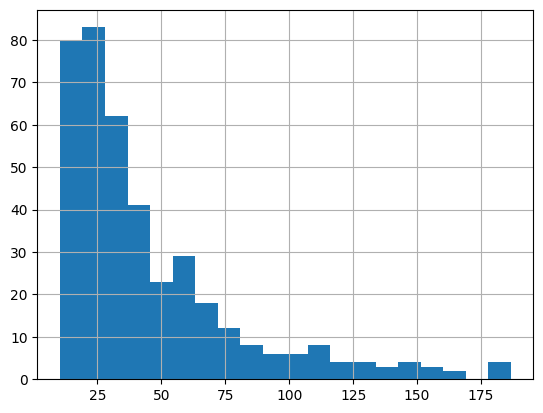

In [ ]:
df['Income'].hist(bins=20)    # il parametro 'bins' rappresenta il numero di barre verticali dell'istogramma; più barre = più dettagli, meno barre = meno dettagli ma più leggibile

Come si vede, la distribuzione del reddito è fortemente **assimetrica destra**. E' tipico di molti indicatori finanziari: reddito, fatturato, ecc.

**📌 Nota sul subsetting di colonna**

pandas ha due tipi di **data-type aggregati**: il **dataframe** (righe e colonne) e **la serie**, composta da un vettore (serie di elementi).

"Subsetting" di colonna = estrazione dal dataframe di una sola specifica colonna (o più specifiche colonne). Si fa sempre con le parentesi quadre (con dentro il nome della/delle colonna/colonne.<br>
Subsetting con $[.]$ ⟶ una **serie** pandas<br>
Subsetting con $[[.]]$ ⟶ un **dataframe** pandas con **1 colonna sola**.<br>

In [36]:
print(df.shape)
print(df['Income'].shape)
print(type(df['Income']))

print(df[['Income']].shape)
print(type(df[['Income']]))

(400, 11)
(400,)
<class 'pandas.Series'>
(400, 1)
<class 'pandas.DataFrame'>


⚠️ Queste 2 classi hanno **metodi differenti**! (a parte alcuni: `head`, `tail`, `shape`, `describe`, `mean`, `median`, ecc).

In [37]:
# 4 esempi di metodi identici per dataframe e serie di pandas (con differenze di sintassi e di output):
print(df['Income'].shape)
print(df[['Income']].shape)
print(df['Income'].head())
print(df[['Income']].head())
print(df['Income'].mean())
print(df[['Income']].mean().item())
print(df['Income'].describe())
print(df[['Income']].describe())

(400,)
(400, 1)
0     14.891
1    106.025
2    104.593
3    148.924
4     55.882
Name: Income, dtype: float64
    Income
0   14.891
1  106.025
2  104.593
3  148.924
4   55.882
45.218885
45.218885
count    400.000000
mean      45.218885
std       35.244273
min       10.354000
25%       21.007250
50%       33.115500
75%       57.470750
max      186.634000
Name: Income, dtype: float64
           Income
count  400.000000
mean    45.218885
std     35.244273
min     10.354000
25%     21.007250
50%     33.115500
75%     57.470750
max    186.634000


Altri metodi sono invece **propri solo delle serie e non dei dataframe**; ad esempio: `unique` oppure `dtype`.    

In [38]:
# Il metodo 'unique', che elenca i valori UNICI della colonna, funziona solo per le serie di pandas, non per i dataframe (anche se il dataframe contiene una sola colonna)
df['Gender'].unique()    # --> ok, funziona
df[['Gender']].unique()    # --> no, non funziona

AttributeError: 'DataFrame' object has no attribute 'unique'

Vale anche **il caso opposto**: metodi pandas applicabili solo ai dataframe e non alle serie; ad esempio: `groupby`, `merge` e `join`:

Il comportamento del subsetting in pandas può sembrare inconsistente: in realtà, occore capire la differenza tra le due forme di subsetting $[.]$ e $[[.]]$.<br>

Con il subsetting di colonna con le doppie $[[.]]$ possiamo estrarre **anche più di una colonna**:


In [39]:
df[["Income","Balance"]]

,Income,Balance
0,14.891,333
1,106.025,903
2,104.593,580
3,148.924,964
4,55.882,331
...,...,...
395,12.096,560
396,13.364,480
397,57.872,138
398,37.728,0


In [ ]:
# lo stesso subsetting con le [] singole ovviamente dà errore, perché pandas interpreta la sintassi come un tentativo di selezionare una colonna con il nome "Income","Balance" (che non esiste) 
# e non come un tentativo di selezionare due colonne distinte.
df["Income","Balance"]

KeyError: ('Income', 'Balance')

**Fine della nota sul subsetting di colonna**.

Vediamo ora un secondo importante plot: il [boxplot](https://it.wikipedia.org/wiki/Diagramma_a_scatola_e_baffi), qui appliactol sempre alla colonna *Income*:

<Axes: >

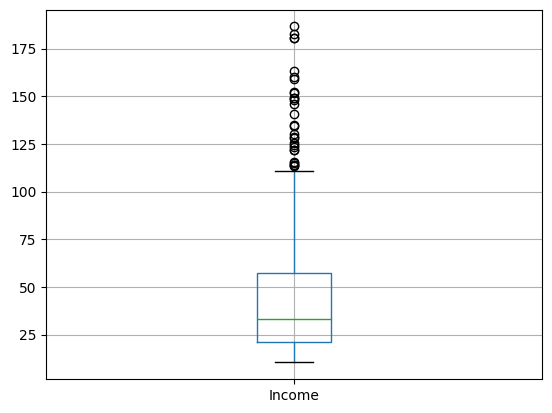

In [43]:
df[['Income']].boxplot()

I baffi esprimono l'[IQR](https://it.wikipedia.org/wiki/Scarto_interquartile) (Inter Quartile Range), cioè la differenza tra Q3 (75%) e Q1 (25%), moltiplicato per 1.5. E' una convenzione che permette di inviduare eventuali outlier, cioè valori "anomali".

I due plot che abbiamo visto (istogramma e boxplot) sono **complementari**:
* l'istogramma evidenzia bene la **forma** della distribuzione dei dati
* il boxplot evidenzia bene i **quartili** (25,50,75) e **outlier**.

In [44]:
q1 = df[["Income"]].quantile(0.25)
q3 = df["Income"].quantile(0.75)

iqr = q3 - q1

print(iqr)

Income    36.4635
Name: 0.25, dtype: float64


⭐ **Prima giornata (16.6.2026): arrivati qui.**

Calcoliamo la fondamentale **matrice di correlazione**:

In [ ]:
df.corr()    # --> dà errore perchè le correlazioni sono calcolabili solo tra coppie di variabili numeriche

In [ ]:
df.select_dtypes('number')

In [ ]:
df.select_dtypes('object')

In [ ]:
round(df.select_dtypes('number').corr(),2)

La matrice di correlazione è quadrata e simmetrica. Sulla diagonale principale ci sono tutti 1 -> la correlazione infatti è un coefficiente tra 0 e 1 (se positiva) e tra 0 e -1 (se negativa).

Vogliamo estrarre solo la matrice traingolare superiore.

In [ ]:
import numpy as np    #  un altro package di python fondamentale;
                      #  serve per molti calcoli numerici;
                      #  per convenzione è importato come 'np'

correlation_matrix = df.select_dtypes('number').corr()
upper_triangular_matrix = np.triu(correlation_matrix)
display(upper_triangular_matrix)   # numpy lavora internamente con le ARRAY (numeriche) e non i dataframe
                                   # quindi restituisce una array (una matrice numerica) SENZApiùi nomi delle colonne
mat_corr_upper = pd.DataFrame(upper_triangular_matrix, columns=df.select_dtypes('number').columns)
                                   # 'pd.DataFrame' è una FUNZIONE con la lista degli argomenti tra ();
                                   # invece 'select_dtypes' e 'columns' sono 2 METODI della classe DataFrame e si scrivono A VALLE dell'oggetto
display(round(mat_corr_upper,2))

La seguente cella è stata generata dall'**assistente AI**: avevamo chiesto come NON visualizzare la matrice triangolare inferiore (neanche gli 0)

In [ ]:
# Hide the lower triangular part (including the diagonal)
def hide_lower_triangular(val):
    return 'visibility: hidden' if val == 0 else ''

# Apply the styling to the upper triangular matrix
styled_matrix = mat_corr_upper.style.map(hide_lower_triangular)
display(styled_matrix)


L'indice di correlazione tra Rating e Limit è altissimo (0.9968). Vuol dire che c'è una fortissima **associazione** tra le due variabili, non necessariamente un rapporto causa effetto. Un esempio migliore è la correlazione tra Balance e Limit (0.86): il limite è deciso dalla banca unicamente sulla base del Balance? Probabilmente, no.

Se ci fosse un rapporto causa-effetto tra due variabili correlate (ad esempio Balance e Limit), le troveremmo correlate in OGNI campione di questa popolazione di questa banca.

In QUESTO campione abbiamo rilevato una semplice ASSOCIAZIONE, che potrebbe benissimo non ripetersi in un altro campione.

In italiano e in inglese: correlazione vuol dire rapporto "causa-effetto". L'uomo della srrada intende così la correlazione.

**Rename** di un nome colonna

In [ ]:
df.rename(columns={'Balance': 'Balance_card'}, inplace=True)
df

**Campionamento casuale**:

In [ ]:
df.sample(n=10)   # utile per esaminare il dataset

In [ ]:
df.sample(n=10, random_state=1000) # con seme, per garantire la "riproducibilità dei risultati"

***Shuffling*** = rimescolamento (NON per serie temporali).<br>
E' buona norma RIMESCOLARE un dataframe prima di applicare ad esso un modello di Machine Learning, poichè il dataframe potrebbe essere ORDINATO rispetto a qualche colonna, e cioò può essere un problema per alcuni modelli.<br>
L'ispezione manuale (visiva) degli eventuali ordinamenti è possibile solo se il dataframe ha poche colonne.


In [ ]:
n = df.shape[0]                           # il numero di righe del dataframe
df_sample = df.sample(n,random_state=1)   # il trucco è qua, il campionamento è fatto su TUTTE le righe,
                                          # SENZA RI-IMMISSIONE del cliente estratto nell'urna (il dataframe),
                                          #  e quindi costituisce uno shuffling
display(df_sample)

Tabelle di contingenza (**frequenze**)

In [ ]:
# df['Gender'].value_counts
df[['Gender']].value_counts()

Vediamo ora la **cross-reference**, cioè la tabella degli incroci tra due colonne (anche detta **tabella di conmtingenza a 2 fattori**.)

In [ ]:
# questo NON è un METODO ma è una FUNZIONE
# un metodo si può applicare solo agli oggetti (cioè variabili) di una CERTA CLASSE,
# il concetto di funzione è più ampio e meno restrittivo
# 'pd.crosstab' è una FUNZIONE
pd.crosstab(index=df['Gender'],columns=df['Married'])

Gli **indici**:

In [ ]:
df.index         # quello CORRENTE, non necessariamente quello INIZIALE creato automaticamente
                 # da pandas (un progressivo da 0 in poi)
                 # l'indice serve a velocizzare gli accessi.

Possiamo modificare l'indice, ad esempio per la colonna 'Education'

In [ ]:
df.set_index('Education',inplace=True)
df

In [ ]:
df.index        # fornisce l'elenco dei valori (tutti e 400!) del NUOVO indice corrente (Education)

In [ ]:
df.index.is_unique   # test booleano sulla unicità dei valori dell'indice corrente

In [ ]:
df.index.unique()    # lista dei valori dell'indice unici

Una colonna indicizzata non è più subsettabile:

In [ ]:
df['Education'].head()

Il bottone "Spiega errore" ha fornito la seguente risposta:<br>
> *L'errore KeyError: 'Education' nella cella corrente si è verificato perché la colonna 'Education' è stata impostata come indice del DataFrame utilizzando **df.set_index('Education', inplace=True)**. Una volta che una colonna diventa l'indice, non è più accessibile come una normale colonna utilizzando la sintassi standard df['nome_colonna'].*

> *Per accedere all'indice, puoi usare **df.index**. Per visualizzare i primi valori dell'indice, puoi usare **df.index.head()**.*

> *Se hai bisogno di accedere nuovamente a 'Education' come una normale colonna, puoi resettare l'indice usando **df.reset_index(inplace=True**).*

In [ ]:
df.index.head()      # suggerito da Gemini sopra --> un'allucinazione!

Uno dei vantaggi dell'argomento 'inplace=True' (disponibile per molti metodi pandas) è di **evitare la proliferazione inutile di dataframe**. Un'alternativa sarebbe infatti:
df2 = df.copy()

In [ ]:
df2 = df         # non crea una copia, crea solo un secondo puntatore al medesimo dataframe - può creare problemi, nel senso che, se modifico  'df' per qualche aspetto
                 # risulta modificato anche 'df2'

df2 = df.copy()  # crea una copia del primo dataframe, AUTONOMA --> consumo di memoria se i dataframe sono grandi
                 # attenzione: `df.copy` (senza parentesi) non è corretto e fa altro!

La proliferazione di dataframe inoltre confonde e rende più difficile la comprensione del codice.

**Quali sono i criteri per decidere la colonna (o le colonne) da indicizzare?**<br>
I criteri per decidere quale colonna del dataframe df ti conviene indicizzare dipendono principalmente da come intendi accedere ai dati. Ecco i punti chiave da considerare:
- **Accesso frequente e veloce per valore**: Se prevedi di cercare o recuperare righe molto spesso in base ai valori di una specifica colonna (ad esempio, cercare clienti per ID, o prodotti per codice), rendere quella colonna l'indice può velocizzare notevolmente queste operazioni. Gli indici in pandas funzionano in modo simile agli indici nei database, creando una struttura dati ottimizzata per le ricerche.
- **Unicità dei valori**: Se la colonna contiene valori univoci per ogni riga (come un ID cliente o un codice fiscale), è un ottimo candidato per diventare l'indice. Un indice univoco garantisce che ogni riga sia identificata in modo non ambiguo.
- **Ordinamento dei dati**: Se hai bisogno di accedere frequentemente a intervalli di righe basati sui valori di una colonna (ad esempio, tutte le transazioni in un determinato intervallo di date se la colonna è una data), impostare quella colonna come indice e ordinarla può migliorare le prestazioni.
- **Join e merge** (RARO): Quando esegui operazioni di join o merge tra dataframe, se i dataframe sono indicizzati sulla colonna che usi per il join, l'operazione sarà generalmente più veloce.
- **Significato dei dati**: A volte, una colonna ha un significato intrinseco che la rende un buon candidato per l'indice, anche se non è strettamente necessario per le prestazioni. Ad esempio, in un dataframe di serie temporali, la colonna della data/ora è quasi sempre l'indice naturale.

**Quando NON conviene indicizzare?**
- Se la colonna ha **molti valori duplicati** e non hai bisogno di accedere rapidamente a gruppi specifici basati su quei valori.
- Se modifichi frequentemente l'indice del dataframe, poiché la creazione e la gestione dell'indice hanno **un costo computazionale**.
- Se **l'ordine delle righe ORIGINALE è importante** e non vuoi che venga modificato dall'ordinamento implicito che può derivare dall'impostazione di un indice.

Nel caso del tuo dataframe 'df', colonne come 'ID' (se fosse ancora presente e univoca) o forse 'Education' (se volessi raggruppare o accedere spesso per livello di istruzione) potrebbero essere considerate come indici, **a seconda dell'analisi che intendi svolgere**.

> Tuttavia, per molte analisi esplorative di base, l'indice numerico di default è perfettamente adeguato.


Possiamo resettare l'indice a quello originale:

In [ ]:
df.reset_index(inplace=True)  # come sempre, l'argomento 'inplace=True' NON visualizza nulla ma modifica l'oggetto in memoria

In [ ]:
df.head()

Cambiamo argomento, vediamo i metodi *style*:

Il metodo `style`, che ha molti **sottometodi**; vediamo i principali:

In [ ]:
df.select_dtypes('number').head().style.map(lambda v: 'color: red' if v < 20 else '')
                                                 # questa funzione lambda evidenzia in ROSSO i valori (di tutte le colonne NUMERICHE) < 20)
                                                 # notate l'applicazione IN CASCATA di 3 metodi

Una applicazione più frequente del metodo 'style' è **sulla singola colonna con cutoff specifico per colonna**
:

In [ ]:
df[['Income']].head().style.map(lambda v: 'color: red' if v > 100 else '')

NB. df[['Income']] è un dataframe. Invece,df['Income'] è una serie, che non dispone del metodo style --> errore!!

In [ ]:
df['Income'].head().style.map(lambda v: 'color: red' if v > 100 else '')   # --> Series' object has no attribute 'style'

Altri tipi di uso di style:

In [ ]:
display(df.select_dtypes('number').head(10).style.bar(subset=['Income'], color='lightblue'))
df.select_dtypes('number').head(10).style.bar(subset=['Income', 'Balance_card'], color='#d65f5f')

In [ ]:
df.head().style.background_gradient(cmap='coolwarm')  # lo schema di colori qui scelto visualizza, per OGNI colonna NUMERICA del dataframe, in gradazioni di rosso i valori
                                                      # più alti e in gradazioni di blu quelli più bassi (non in assoluto, ma relativamente ad ogni colonna)

In [ ]:
df.select_dtypes('number').style.highlight_max(axis=0,color='red')  # identifica (qui in rosso) il valore MAX di ogni colonna

Con il metodo `style` possiamo ora **visualizzare meglio la matrice di correlazione**:

In [ ]:
df.select_dtypes('number').corr().style.background_gradient(cmap='coolwarm')

**Nota sul metodo 'style'**:<br>
La valutazione 'alto' o 'basso' è sempre **relativa** agli altri valori di QUELLA colonna singola, valutata **indipendentemente** dalle altre.

Cambiamo argomento. Passiamo al **subsetting**, cioè l'estrazione da un dataframe o da una serie pandas di un **sottoinsieme di righe e/o colonne**.<br>
Abbiamo già visto numerosi esempi di **subsetting di colonna**.<br>
Vediamo ora il subsetting di **riga**:

In [ ]:
df[1:3]        # attenzione a 2 cose: a. python conta da 0, b. l'estremo superiore non è (n), ma (n+1)

In [ ]:
df['Income'][1:3]        # subsetting di colonna e riga

> Il subsetting permette di **focalizzare** l'analisi su una **porzione** del dataframe.

**Trasformazione** di una variabile categorica (da numerica a fattore).<br>
La variabile 'gender' (come anche le variabili 'Married', 'Student', ecc) è stata caricata in pandas come 'object' (stringa). E' meglio trasformare le variabili 'gender', 'married', ecc in variabili CATEGORICHE.<br>
Nella Data Science ci sono infatti due tipi di variabili:
- numeriche
- categoriche

La differenza è che le prime possono assumere un numero INFINITO di valori, le secondo un numero FINITO.


In [ ]:
df['Gender'] = df['Gender'].astype('category')
df.dtypes

In [ ]:
df.select_dtypes(['category'])

**Ordinamenti**:

In [ ]:
df.sort_values(by = 'Income', ascending = True,inplace=False) # senza 'inplace=True', altrimenti diventa permanente;

In [ ]:
df.head()

**Raggruppamenti**: solo sulle colonne <u>numeriche</u>, applicando ad ogni gruppo una <u>funzione statistica</u> (media, mediana, ecc)

In [ ]:
df.select_dtypes('number').groupby(by='Age').mean()

Se ai gruppi si applica un metodo non statistico (ad es. 'head()') la group_by non viene eseguita (provare).

Se ai gruppi non viene applicata nessuna funzione, non sono visualizzati risultati (provare).

La **standardizzazione** dei dati NUMERICI è spesso usata nella Data Science. Serve a trasformare una o più colonne NUMERICHE del dataframe nel range -6 +6 con media 0. Cioè, in altre parole, serve a **ricondurre tutte le colonne ad una stessa scala**.

La seguente cella utilizza la famosa libreria [**scikit-learn**](https://scikit-learn.org/stable/) per il Machine Learning in Python e la funzione *scale* del modulo *pre-processing*:

In [ ]:
import numpy as np                                        # numpy, pandas, matplotlib, ecc sono package STANDALONE e quindi si importano a se

from sklearn import preprocessing                         # scikit-learn è molto GRANDE e contiene molti moduli - si importa solo il modulo 'pre-processing'
                                                          # che contiene MOLTE funzioni di pre-elaborazione


np.set_printoptions(suppress=False)                       # sopprime l'uso della notazione scientifica per piccoli numeri: # imposta la precisione dell'output della mantissa
                                                          # (se tutte le cifre decimali danno fastidio).

arr_std = preprocessing.scale(df.select_dtypes('number')) # la standardizzazione si può fare solo su colonne numeriche

print(type(arr_std))                                      # numpy ha preso un dataframe pandas in input e ha restituito una array numpy
print(arr_std.shape)                                      # il metodo 'shape' (le dimensioni dell'oggetto) è uno dei pochi disponibili sia in pandas che numpy

arr_std                                                   # --> l'elenco dei 400 clienti (con 7 colonne numeriche) STANDARDIZZATI

In [ ]:
df.head()

Un dataset standardizzato NON è più comprensibile all'utente, ma è utile e comodo in molti casi. Vediamone uno:

In [ ]:
df.boxplot()                    # boxplot comparato fianco a fianco di TUTTE le colonne NUMERICHE del dataframe
                                # un SOLO comando, senza ciclo di for, grazie al funzionamento VETTORIALE (cioè parallelo) di pandas

Poichè le scale delle varie colonne sono **molto differenti** la comparazione è impossibile. Un semplice modo per risolvere questo problema è visualizzare i dati standardizzati.

Siccome le array numpy non hanno il metodo 'boxplot' dobbiamo prima trasformare l'array numpy in un dataframe pandas.

In [ ]:
# creiamo un nuovo dataframe, i nomi di colonna li dobbiamo prendere dal dataframe numerico originario.
# le array numpy non hanno infatti i nomi colonna, nel senso che sono andati persi quando prima abbiamo chiamato
# la funzione 'scale'
df_comp = pd.DataFrame(arr_std, columns=df.select_dtypes('number').columns)
df_comp.boxplot()

I boxplot sono ora confrontabili perchè **sulla stessa scala**. Vediamo:
- quali colonne hanno  outlier
- quali colonne hanno una escursione di valori maggiore
- quali colonne sono distribuite in modo simmetrico oppure no
- ecc

---
Una array di numpy è un oggetto **multi-dimensionale** (un vettore, una matrice, un cubo --> un tensore), nel quale le celle hanno tutte lo stesso datatype.<br>
I dataframe pandas sono **eterogenei**, cioè ogni colonna può avere il suo data-type. Le array numpy sono **omogenee**, in genere numeriche.

---

Le **serie**

In [ ]:
s = pd.Series([10,2,23,4])
s

In [ ]:
type(s)

In [ ]:
s.shape

In [ ]:
s.index

Le colonne di un dataframe sono 'serie'. In altri termini, un dataframe pandas è la somma di tante colonne:

In [ ]:
type(df['Income'])

dataframe e serie hanno molti metodi differenti (alcuni in comuni)

In [ ]:
display(s.shape)
display(df.shape)

In [ ]:
s.boxplot  # ce l'ha solo il dataframe

# I Data Type
Le seguenti immagini descrivono, nell'ordine, i data type di **Python, Pandas e Numpy**, e li confrontano:

In [ ]:
Image('python_data_types.png') if IN_COLAB else display(Image(filename='python_data_types.png'))

In [ ]:
Image('python_data_types2.png') if IN_COLAB else display(Image(filename='python_data_types2.png'))

In [ ]:
Image('Series_vs_Dataframe.png') if IN_COLAB else display(Image(filename='Series_vs_Dataframe.png'))

In [ ]:
Image('pandas_data_types.png') if IN_COLAB else display(Image(filename='pandas_data_types.png'))

In [ ]:
Image('numpy_array.png') if IN_COLAB else display(Image(filename='numpy_array.png'))

La seguente immagine confronta un dataframe con una array.

In [ ]:
Image('df_vs_array.png') if IN_COLAB else display(Image(filename='df_vs_array.png'))

Segue nella sottostante un confronto dei **data type elementari (atomici)** di pandas, python e numpy.<br>
Sono esclusi da questo confronto i **data type strutturati**, cioè:
- `dataframe` e `serie` per *pandas*
- `array` per *numpy*
- `set`, `dict` e `sequence` per *python*

In [ ]:
Image('data_types_mapping.png') if IN_COLAB else display(Image(filename='data_types_mapping.png'))